{% def title Neural Networks With Matrices %}
{% def date 2023-07-30 %}
{% def tags machine-learning %}

{% template blog_post.html title date tags %}

There are a lot of online resources that show how neural networks works with scalar values[^1] (probably because it's easy to understand), but there are not enough of them talking about doing it using matrices. So, in this article I will build it up step by step on a single dense layer.

In [1]:
# {% out_only %}
import matplotlib.pyplot as plt
from IPython.display import SVG, display_svg
import io

def latex_text_to_svg(latex_expression):
    f = plt.figure(dpi=100)
    t = f.text(0, 0, f'${latex_expression}$', size=16, usetex=True)
    bb = t.get_window_extent()
    buffer = io.BytesIO()
    plt.gcf().set_size_inches(bb.width / 100, bb.height / 100)
    plt.axis('off')
    plt.savefig(buffer, format='svg', bbox_inches='tight')
    plt.close()
    display_svg(SVG(data=buffer.getvalue().decode()))
    buffer.close()

## Forward pass

First, let's go through forward pass using a single neuron.

- Each neuron in a network has a set of inputs which it receives from previous layer. We collect these in a vector and name that vector x. Each of the inputs can be represented as x<sup>i</sup>, where i is the corresponding input node.
- For each of these inputs, we have weights associated with it which tell how important that input is for the neuron. Let's put all these weights into a vector and call it w. We use the same notation as x for weights too.
- Let's call the neuron N.

Graphically, this is what a neuron will look like:

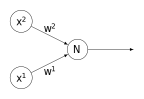

In [13]:
# {% out_only %}
from IPython.display import SVG, display
display(SVG('<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" version="1.1" width="300pt" height="200pt" viewBox="0 0 144.854 99.306"> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M10.32663 0C10.32663 5.70331 5.70331 10.32663 0 10.32663-5.70331 10.32663-10.32663 5.70331-10.32663 0-10.32663-5.70331-5.70331-10.32663 0-10.32663 5.70331-10.32663 10.32663-5.70331 10.32663 0ZM0 0"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-46.249" x="73.454">N</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-45.54874-28.3468C-45.54874-22.19159-50.53839-17.20193-56.69362-17.20193-62.84883-17.20193-67.83849-22.19159-67.83849-28.3468-67.83849-34.50203-62.84883-39.49168-56.69362-39.49168-50.53839-39.49168-45.54874-34.50203-45.54874-28.3468ZM-56.69362-28.3468"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-17.252" x="16.225">x</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-20.867" x="21.919">1</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-45.54874 28.3468C-45.54874 34.50203-50.53839 39.49168-56.69362 39.49168-62.84883 39.49168-67.83849 34.50203-67.83849 28.3468-67.83849 22.19159-62.84883 17.20193-56.69362 17.20193-50.53839 17.20193-45.54874 22.19159-45.54874 28.3468ZM-56.69362 28.3468"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-73.945" x="16.225">x</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 .0000019073487 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-77.56" x="21.919">2</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-46.54784-23.274-12.62161-6.31068"/> <path transform="matrix(.89436,-.44717,-.44717,-.89436,65.37737,55.9637)" d="M3.58653 0C2.52383 .19925 .797 .797-.3985 1.49438V-1.49438C.797-.797 2.52383-.19925 3.58653 0"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-24.033" x="44.084">w</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-27.649" x="51.485">1</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M-46.54784 23.274-12.62161 6.31068"/> <path transform="matrix(.89436,.44717,.44717,-.89436,65.37737,43.3423)" d="M3.58653 0C2.52383 .19925 .797 .797-.3985 1.49438V-1.49438C.797-.797 2.52383-.19925 3.58653 0"/> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="9.9626" font-family="CMMI10" font-style="italic"><tspan y="-67.163" x="44.084">w</tspan></text> <text xml:space="preserve" transform="matrix(1 0 -0 1 0 99.306)" font-size="6.9738" font-family="CMR7"><tspan y="-70.778" x="51.485">2</tspan></text> <path transform="matrix(1,0,0,-1,77.999,49.653)" stroke-width=".3985" stroke-linecap="butt" stroke-miterlimit="10" stroke-linejoin="miter" fill="none" stroke="#000000" d="M10.5259 0H53.10709"/> <path transform="matrix(1,0,0,-1,131.1061,49.653)" d="M3.58653 0C2.52383 .19925 .797 .797-.3985 1.49438V-1.49438C.797-.797 2.52383-.19925 3.58653 0"/></svg>'))

There three things going on inside the neuron:

1. Weighted sum of the inputs
2. Adding of neuron bias to the weighted sum
3. Passing the weighted sum into the activation function

Mathematically, it looks like this:

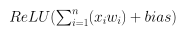

In [15]:
# {% out_only %}
latex_text_to_svg(r'ReLU(\sum_{i=1}^{n} (x_iw_i) + bias)')

Here ReLU (Rectified Linear Unit) is the activation function. It decides whether a neuron should fire or not. The summation part is the weighted sum that we were talking about. It is same as multiplying the input with corresponding weights and adding all the terms. Bias is used to offset the result.

Since a single neuron's weights are represented as a vector, a layer of these neurons will be represented as a matrix. Let's name that matrix W. But what about input vector x? Since the same inputs are fed into all the neurons, it remains a vector.

When we do a dot product the input vector and the weight matrix we get the summations on all the neurons in the layer.

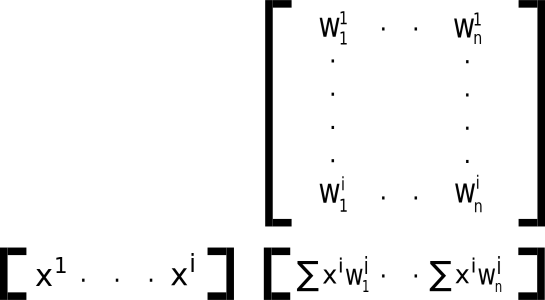

In [4]:
# {% out_only %}
from IPython.display import SVG, display
display(SVG('<svg width="545.965" height="300.346" viewBox="0 0 144.453 79.466" xmlns="http://www.w3.org/2000/svg"> <text xml:space="preserve" style="font-size:7.76111px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="32.621" y="137.618" transform="translate(-22.447 -63.677)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" transform="rotate(180 -11.223 -31.722)" d="M-84.455-142.911h2v13.878h-2z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" transform="rotate(180 -11.223 -31.722)" d="M-82.455-142.911h5v2h-5zM-82.455-131.033h5v2h-5z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" d="M22.447 129.604h2v13.878h-2z" transform="translate(-22.447 -64.015)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M24.447 129.604h5v2h-5zM24.447 141.482h5v2h-5z" transform="translate(-22.447 -64.015)"/> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="31.693" y="139.498" transform="translate(-22.447 -63.73)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="31.693" y="139.498">x</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.731" y="136.043" transform="translate(-22.447 -63.73)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.731" y="136.043">1</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="67.561" y="139.282" transform="translate(-22.447 -63.73)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="67.561" y="139.282">x</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="72.599" y="135.827" transform="translate(-22.447 -63.73)"><tspan style="stroke-width:.264583" x="72.599" y="135.827">i</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="43.525" y="138.404" transform="translate(-22.447 -63.73)"><tspan style="stroke-width:.264583" x="43.525" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="61.459" y="138.404" transform="translate(-22.447 -63.73)"><tspan style="stroke-width:.264583" x="61.459" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="52.492" y="138.404" transform="translate(-22.447 -63.73)"><tspan style="stroke-width:.264583" x="52.492" y="138.404">.</tspan></text> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M104.228 63.713h2v60h-2z" transform="translate(-33.94 -63.713)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M106.228 63.713h5v2h-5zM106.228 121.713h5v2h-5z" transform="translate(-33.94 -63.713)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" transform="rotate(180 -4.269 -31.856)" d="M-152.991-123.713h2v60h-2z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" transform="rotate(180 -4.269 -31.856)" d="M-150.991-123.713h5v2h-5zM-150.991-65.713h5v2h-5z"/> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.056" y="116.51" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="123.056" y="116.51">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.643" y="116.51" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="131.643" y="116.51">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.056" y="71.763" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="123.056" y="71.763">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.643" y="71.763" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="131.643" y="71.763">.</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="120.575" y="65.061" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="stroke-width:.336746" x="120.575" y="65.061">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="126.676" y="62.13" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="126.676" y="62.13">1</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="126.676" y="66.856" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="126.676" y="66.856">1</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="120.575" y="104.073" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="stroke-width:.336746" x="120.575" y="104.073">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="127.326" y="101.1" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="127.326" y="101.1">i</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="126.725" y="106.135" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="126.725" y="106.135">1</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="80.219" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="80.219">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="89.022" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="89.022">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="106.628" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="106.628">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="97.825" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="97.825">.</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="161.085" y="103.975" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="stroke-width:.336746" x="161.085" y="103.975">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="166.983" y="106.293" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="166.983" y="106.293">n</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="167.596" y="100.757" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="167.596" y="100.757">i</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="160.781" y="65.247" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="stroke-width:.336746" x="160.781" y="65.247">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="166.816" y="66.738" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="166.816" y="66.738">n</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="166.786" y="62.407" transform="matrix(.88634 0 0 1.12824 -22.447 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="166.786" y="62.407">1</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="80.429" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="80.429">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="89.232" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="89.232">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="106.838" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="106.838">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="98.035" transform="translate(-22.447 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="98.035">.</tspan></text> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" transform="rotate(180 -11.223 -31.669)" d="M-166.831-142.804h2v13.878h-2z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" transform="rotate(180 -11.223 -31.669)" d="M-164.831-142.804h5v2h-5zM-164.831-130.927h5v2h-5z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" d="M92.373 128.927h2v13.878h-2z" transform="translate(-22.447 -63.338)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M94.373 128.927h5v2h-5zM94.373 140.804h5v2h-5z" transform="translate(-22.447 -63.338)"/> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 -22.447 -63.338)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 -22.447 -63.338)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 -22.447 -63.338)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">1</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="107.833" y="138.425" transform="translate(-22.447 -63.338)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="107.833" y="138.425">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(-22.447 -63.338)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="98.141" y="138.85" transform="translate(-22.447 -63.338)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="98.141" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="168.136" y="122.975" transform="matrix(.88634 0 0 1.12824 -22.447 -63.338)"><tspan style="stroke-width:.281546" x="168.136" y="122.975">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.781" y="120.489" transform="matrix(.88634 0 0 1.12824 -22.447 -63.338)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="173.781" y="120.489">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.278" y="124.699" transform="matrix(.88634 0 0 1.12824 -22.447 -63.338)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="173.278" y="124.699">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="142.992" y="138.403" transform="translate(-22.447 -63.338)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="142.992" y="138.403">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="147.204" y="135.515" transform="translate(-22.447 -63.338)"><tspan style="stroke-width:.221212" x="147.204" y="135.515">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="133.3" y="138.828" transform="translate(-22.447 -63.338)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="133.3" y="138.828"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.047" y="136.873" transform="translate(-22.447 -63.338)"><tspan style="stroke-width:.264583" x="123.047" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.634" y="136.873" transform="translate(-22.447 -63.338)"><tspan style="stroke-width:.264583" x="131.634" y="136.873">.</tspan></text> </svg> '))

Here the subscript on the weights denote a neuron in the layer of n neurons. Each column in the weights matrix represent a neuron's weights. Since, each input has a corresponding weight, the number of columns in input vector is same as the number of rows in the weights matrix.

Finally, we add the bias represented as a vector B (since there are n neurons, the size of vector B is also n).

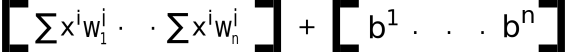

In [5]:
# {% out_only %}
from IPython.display import SVG, display
display(SVG('<svg width="567.73" height="52.451" viewBox="0 0 150.212 13.878" xmlns="http://www.w3.org/2000/svg"> <text xml:space="preserve" style="font-size:7.76111px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="32.621" y="137.618" transform="translate(-22.745 -95.547)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" transform="rotate(180 32.878 -64.516)" d="M-84.455-142.911h2v13.878h-2z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" transform="rotate(180 32.878 -64.516)" d="M-82.455-142.911h5v2h-5zM-82.455-131.033h5v2h-5z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" d="M22.447 129.604h2v13.878h-2z" transform="translate(65.757 -129.604)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M24.447 129.604h5v2h-5zM24.447 141.482h5v2h-5z" transform="translate(65.757 -129.604)"/> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="31.693" y="139.498" transform="translate(65.757 -129.318)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="31.693" y="139.498">b</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.731" y="136.043" transform="translate(65.757 -129.318)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.731" y="136.043">1</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="67.561" y="139.282" transform="translate(65.757 -129.318)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="67.561" y="139.282">b</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="72.599" y="135.476" transform="translate(65.757 -129.318)"><tspan style="stroke-width:.264583" x="72.599" y="135.476">n</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="43.525" y="138.404" transform="translate(65.757 -129.318)"><tspan style="stroke-width:.264583" x="43.525" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="61.459" y="138.404" transform="translate(65.757 -129.318)"><tspan style="stroke-width:.264583" x="61.459" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="52.492" y="138.404" transform="translate(65.757 -129.318)"><tspan style="stroke-width:.264583" x="52.492" y="138.404">.</tspan></text> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" transform="rotate(180 -46.187 -64.463)" d="M-166.831-142.804h2v13.878h-2z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" transform="rotate(180 -46.187 -64.463)" d="M-164.831-142.804h5v2h-5zM-164.831-130.927h5v2h-5z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127246" d="M92.373 128.927h2v13.878h-2z" transform="translate(-92.373 -128.927)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M94.373 128.927h5v2h-5zM94.373 140.804h5v2h-5z" transform="translate(-92.373 -128.927)"/> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 -92.373 -128.927)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 -92.373 -128.927)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 -92.373 -128.927)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">1</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="107.833" y="138.425" transform="translate(-92.373 -128.927)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="107.833" y="138.425">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(-92.373 -128.927)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="98.141" y="138.85" transform="translate(-92.373 -128.927)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="98.141" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="168.136" y="122.975" transform="matrix(.88634 0 0 1.12824 -92.373 -128.927)"><tspan style="stroke-width:.281546" x="168.136" y="122.975">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.781" y="120.489" transform="matrix(.88634 0 0 1.12824 -92.373 -128.927)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="173.781" y="120.489">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.278" y="124.699" transform="matrix(.88634 0 0 1.12824 -92.373 -128.927)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="173.278" y="124.699">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="142.992" y="138.403" transform="translate(-92.373 -128.927)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="142.992" y="138.403">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="147.204" y="135.515" transform="translate(-92.373 -128.927)"><tspan style="stroke-width:.221212" x="147.204" y="135.515">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="133.3" y="138.828" transform="translate(-92.373 -128.927)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="133.3" y="138.828"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.047" y="136.873" transform="translate(-92.373 -128.927)"><tspan style="stroke-width:.264583" x="123.047" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.634" y="136.873" transform="translate(-92.373 -128.927)"><tspan style="stroke-width:.264583" x="131.634" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="101.456" y="104.659" transform="translate(-22.745 -95.547)"><tspan style="stroke-width:.264583" x="101.456" y="104.659">+</tspan></text> </svg>'))

Each of the elements in the resulting vector will be passed on to ReLU activation function as per the formula above. The result of which will also be a vector of size n. This vector will represent the final output of this layer. With this the forward pass will be complete.

There is one thing missing though. Neural networks are trained in batches. The input vector above will actually be a matrix with each row representing a input. If this was the first layer in the network, this will be equivalent to passing in a bunch of rows having i number of columns (features). It is the same for any hidden layer in between.

Therefore, our final output will be a matrix with each row representing the output of all the neurons given the input vectors.

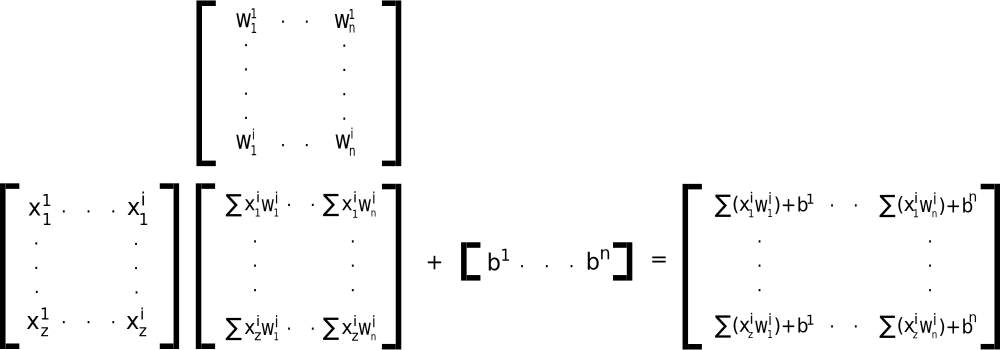

In [9]:
# {% out_only %}
from IPython.display import SVG, display
display(SVG('<svg width="1000" height="350.791" viewBox="0 0 362.141 126.416" xmlns="http://www.w3.org/2000/svg"> <text xml:space="preserve" style="font-size:7.76111px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="32.621" y="137.618" transform="translate(-21.59 -63.677)"/> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="31.693" y="139.498" transform="translate(-21.59 -61.613)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="31.693" y="139.498">x</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.731" y="136.043" transform="translate(-21.59 -61.613)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.731" y="136.043">1</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.827" y="142.913" transform="translate(-21.59 -61.613)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.827" y="142.913">1</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="71.881" y="142.956" transform="translate(-21.59 -61.613)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="71.881" y="142.956">1</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="67.561" y="139.282" transform="translate(-21.59 -61.613)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="67.561" y="139.282">x</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="72.599" y="135.827" transform="translate(-21.59 -61.613)"><tspan style="stroke-width:.264583" x="72.599" y="135.827">i</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="43.525" y="138.404" transform="translate(-21.451 -61.613)"><tspan style="stroke-width:.264583" x="43.525" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="61.459" y="138.404" transform="translate(-21.451 -61.613)"><tspan style="stroke-width:.264583" x="61.459" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="52.492" y="138.404" transform="translate(-21.451 -61.613)"><tspan style="stroke-width:.264583" x="52.492" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="31.693" y="139.498" transform="translate(-22.204 -20.492)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="31.693" y="139.498">x</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.731" y="136.043" transform="translate(-22.204 -20.492)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.731" y="136.043">1</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.871" y="142.051" transform="translate(-22.204 -20.492)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.871" y="142.051">z</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="31.693" y="139.498" transform="translate(13.93 -20.492)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="31.693" y="139.498">x</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.731" y="136.043" transform="translate(13.93 -20.492)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.731" y="136.043">i</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.342" y="142.051" transform="translate(13.93 -20.492)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.342" y="142.051">z</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="43.525" y="138.404" transform="translate(-21.451 -21.482)"><tspan style="stroke-width:.264583" x="43.525" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="61.459" y="138.404" transform="translate(-21.451 -21.482)"><tspan style="stroke-width:.264583" x="61.459" y="138.404">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="52.492" y="138.404" transform="translate(-21.451 -21.482)"><tspan style="stroke-width:.264583" x="52.492" y="138.404">.</tspan></text> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M104.228 63.713h2v60h-2z" transform="translate(-33.083 -63.713)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M106.228 63.713h5v2h-5zM106.228 121.713h5v2h-5z" transform="translate(-33.083 -63.713)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M19.005 130.792h2v60h-2z" transform="rotate(180 41.932 128.506)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M21.005 130.792h5v2h-5zM21.005 188.792h5v2h-5z" transform="rotate(180 41.932 128.506)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M19.005 130.792h2v60h-2z" transform="translate(-19.005 -64.57)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M21.005 130.792h5v2h-5zM21.005 188.792h5v2h-5z" transform="translate(-19.005 -64.57)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" transform="rotate(180 -3.84 -31.856)" d="M-152.991-123.713h2v60h-2z"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" transform="rotate(180 -3.84 -31.856)" d="M-150.991-123.713h5v2h-5zM-150.991-65.713h5v2h-5z"/> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.056" y="116.51" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="123.056" y="116.51">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.643" y="116.51" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="131.643" y="116.51">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.056" y="71.763" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="123.056" y="71.763">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.643" y="71.763" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="131.643" y="71.763">.</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="120.575" y="65.061" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="stroke-width:.336746" x="120.575" y="65.061">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="126.676" y="62.13" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="126.676" y="62.13">1</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="126.676" y="66.856" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="126.676" y="66.856">1</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="120.575" y="104.073" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="stroke-width:.336746" x="120.575" y="104.073">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="127.326" y="101.1" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="127.326" y="101.1">i</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="126.725" y="106.135" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="126.725" y="106.135">1</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="80.219" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="80.219">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="89.022" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="89.022">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="33.031" y="149.391" transform="translate(-20.928 -60.975)"><tspan style="stroke-width:.264583" x="33.031" y="149.391">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="33.031" y="158.194" transform="translate(-20.928 -60.975)"><tspan style="stroke-width:.264583" x="33.031" y="158.194">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="33.238" y="166.956" transform="translate(-20.928 -60.975)"><tspan style="stroke-width:.264583" x="33.238" y="166.956">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="33.031" y="149.391" transform="translate(15.204 -60.81)"><tspan style="stroke-width:.264583" x="33.031" y="149.391">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="33.031" y="158.194" transform="translate(15.204 -60.81)"><tspan style="stroke-width:.264583" x="33.031" y="158.194">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="33.238" y="166.956" transform="translate(15.204 -60.81)"><tspan style="stroke-width:.264583" x="33.238" y="166.956">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="106.628" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="106.628">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="109.663" y="97.825" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="109.663" y="97.825">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="151.599" transform="translate(-202.234 -63.943)"><tspan style="stroke-width:.264583" x="293.567" y="151.599">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="169.205" transform="translate(-202.234 -63.943)"><tspan style="stroke-width:.264583" x="293.567" y="169.205">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="160.402" transform="translate(-202.234 -63.943)"><tspan style="stroke-width:.264583" x="293.567" y="160.402">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="151.599" transform="translate(-166.792 -63.943)"><tspan style="stroke-width:.264583" x="293.567" y="151.599">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="169.205" transform="translate(-166.792 -63.943)"><tspan style="stroke-width:.264583" x="293.567" y="169.205">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="160.402" transform="translate(-166.792 -63.943)"><tspan style="stroke-width:.264583" x="293.567" y="160.402">.</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="161.085" y="103.975" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="stroke-width:.336746" x="161.085" y="103.975">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="166.983" y="106.293" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="166.983" y="106.293">n</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="167.596" y="100.757" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="167.596" y="100.757">i</tspan></text> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="160.781" y="65.247" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="stroke-width:.336746" x="160.781" y="65.247">w</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="166.816" y="66.738" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="166.816" y="66.738">n</tspan></text> <text xml:space="preserve" style="font-size:4.23333px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.336746" x="166.786" y="62.407" transform="matrix(.88634 0 0 1.12824 -21.59 -63.677)"><tspan style="font-size:4.23333px;stroke-width:.336746" x="166.786" y="62.407">1</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="80.429" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="80.429">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="89.232" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="89.232">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="106.838" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="106.838">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="145.299" y="98.035" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264583" x="145.299" y="98.035">.</tspan></text> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M19.005 130.792h2v60h-2z" transform="rotate(180 82.162 128.588)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M21.005 130.792h5v2h-5zM21.005 188.792h5v2h-5z" transform="rotate(180 82.162 128.588)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M19.005 130.792h2v60h-2z" transform="translate(51.896 -64.564)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M21.005 130.792h5v2h-5zM21.005 188.792h5v2h-5z" transform="translate(51.896 -64.564)"/> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 -19.34 -62.454)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 -19.34 -62.454)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 -19.34 -62.454)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">1</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="107.833" y="138.425" transform="translate(-19.34 -62.454)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="107.833" y="138.425">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(-19.34 -62.454)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="98.141" y="138.85" transform="translate(-19.34 -62.454)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="98.141" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="168.136" y="122.975" transform="matrix(.88634 0 0 1.12824 -19.34 -62.454)"><tspan style="stroke-width:.281546" x="168.136" y="122.975">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.781" y="120.489" transform="matrix(.88634 0 0 1.12824 -19.34 -62.454)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="173.781" y="120.489">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.278" y="124.699" transform="matrix(.88634 0 0 1.12824 -19.34 -62.454)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="173.278" y="124.699">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="142.992" y="138.403" transform="translate(-19.34 -62.454)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="142.992" y="138.403">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="147.204" y="135.515" transform="translate(-19.34 -62.454)"><tspan style="stroke-width:.221212" x="147.204" y="135.515">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="133.3" y="138.828" transform="translate(-19.34 -62.454)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="133.3" y="138.828"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.047" y="136.873" transform="translate(-19.34 -62.454)"><tspan style="stroke-width:.264583" x="123.047" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.634" y="136.873" transform="translate(-19.34 -62.454)"><tspan style="stroke-width:.264583" x="131.634" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 -19.34 -17.641)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 -19.34 -17.641)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 -19.34 -17.641)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">1</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="107.833" y="138.425" transform="translate(-19.34 -17.641)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="107.833" y="138.425">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(-19.34 -17.641)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="98.141" y="138.85" transform="translate(-19.34 -17.641)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="98.141" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="168.136" y="122.975" transform="matrix(.88634 0 0 1.12824 -19.34 -17.641)"><tspan style="stroke-width:.281546" x="168.136" y="122.975">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.781" y="120.489" transform="matrix(.88634 0 0 1.12824 -19.34 -17.641)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="173.781" y="120.489">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="173.278" y="124.699" transform="matrix(.88634 0 0 1.12824 -19.34 -17.641)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="173.278" y="124.699">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="142.992" y="138.403" transform="translate(-19.34 -17.641)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="142.992" y="138.403">x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="147.204" y="135.515" transform="translate(-19.34 -17.641)"><tspan style="stroke-width:.221212" x="147.204" y="135.515">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="133.3" y="138.828" transform="translate(-19.34 -17.641)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="133.3" y="138.828"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.047" y="136.873" transform="translate(-19.34 -17.641)"><tspan style="stroke-width:.264583" x="123.047" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.634" y="136.873" transform="translate(-19.34 -17.641)"><tspan style="stroke-width:.264583" x="131.634" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="113.773" y="141.952" transform="translate(-21.59 -63.677)"><tspan style="font-size:3.53939px;stroke-width:.264583" x="113.773" y="141.952">1</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="149.047" y="142.338" transform="translate(-21.59 -63.677)"><tspan style="font-size:3.53939px;stroke-width:.264583" x="149.047" y="142.338">1</tspan></text> <text xml:space="preserve" style="font-size:4.93889px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="113.676" y="186.722" transform="translate(-21.59 -63.677)"><tspan style="font-size:4.93889px;stroke-width:.264583" x="113.676" y="186.722">z</tspan></text> <text xml:space="preserve" style="font-size:4.93889px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="148.862" y="186.9" transform="translate(-21.59 -63.677)"><tspan style="font-size:4.93889px;stroke-width:.264583" x="148.862" y="186.9">z</tspan></text> <text xml:space="preserve" style="font-size:7.76111px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="175.669" y="161.045" transform="translate(-21.59 -63.677)"><tspan style="font-size:7.76111px;stroke-width:.264583" x="175.669" y="161.045">+</tspan></text> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127243" d="M250.577 165.125h-2v-13.877h2z" transform="translate(-21.59 -63.677)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763769" d="M248.578 165.125h-5v-2h5zm0-11.877h-5v-2h5z" transform="translate(-21.59 -63.677)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.127243" d="M188.572 151.247h2v13.877h-2z" transform="translate(-21.59 -63.677)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763769" d="M190.572 151.247h5v2h-5zm0 11.877h5v2h-5z" transform="translate(-21.59 -63.677)"/> <text xml:space="preserve" style="font-size:8.08191px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="31.693" y="139.498" transform="matrix(.99998 0 0 .99998 144.535 -41.745)"><tspan style="font-size:8.08191px;stroke-width:.264583" x="31.693" y="139.498">b</tspan></text> <text xml:space="preserve" style="font-size:5.64444px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="36.731" y="136.043" transform="matrix(.99998 0 0 .99998 144.535 -41.745)"><tspan style="font-size:5.64444px;stroke-width:.264583" x="36.731" y="136.043">1</tspan></text> <text xml:space="preserve" style="font-size:8.08171px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264577" x="233.685" y="161.21" transform="translate(-21.59 -63.677)"><tspan style="font-size:8.08171px;stroke-width:.264577" x="233.685" y="161.21">b</tspan></text> <text xml:space="preserve" style="font-size:6.34984px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264577" x="238.723" y="157.405" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264577" x="238.723" y="157.405">n</tspan></text> <text xml:space="preserve" style="font-size:6.34984px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264577" x="209.65" y="160.333" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264577" x="209.65" y="160.333">.</tspan></text> <text xml:space="preserve" style="font-size:6.34984px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264577" x="227.583" y="160.333" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264577" x="227.583" y="160.333">.</tspan></text> <text xml:space="preserve" style="font-size:6.34984px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264577" x="218.616" y="160.333" transform="translate(-21.59 -63.677)"><tspan style="stroke-width:.264577" x="218.616" y="160.333">.</tspan></text> <text xml:space="preserve" style="font-size:7.76111px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="256.964" y="160.03" transform="translate(-21.59 -63.677)"><tspan style="font-size:7.76111px;stroke-width:.264583" x="256.964" y="160.03">=</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.816" y="138.242" transform="translate(-21.59 -63.677)"/> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="151.599" transform="translate(-19.474 -63.926)"><tspan style="stroke-width:.264583" x="293.567" y="151.599">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="169.205" transform="translate(-19.474 -63.926)"><tspan style="stroke-width:.264583" x="293.567" y="169.205">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="293.567" y="160.402" transform="translate(-19.474 -63.926)"><tspan style="stroke-width:.264583" x="293.567" y="160.402">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="355.283" y="155.809" transform="translate(-19.472 -68.135)"><tspan style="stroke-width:.264583" x="355.283" y="155.809">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="355.283" y="173.415" transform="translate(-19.472 -68.135)"><tspan style="stroke-width:.264583" x="355.283" y="173.415">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="355.283" y="164.612" transform="translate(-19.472 -68.135)"><tspan style="stroke-width:.264583" x="355.283" y="164.612">.</tspan></text> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M19.005 130.792h2v60h-2z" transform="rotate(180 190.573 128.587)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M21.005 130.792h5v2h-5zM21.005 188.792h5v2h-5z" transform="rotate(180 190.573 128.587)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.264583" d="M19.005 130.792h2v60h-2z" transform="translate(228.175 -64.376)"/> <path style="fill:#000;fill-rule:evenodd;stroke-width:.0763788" d="M21.005 130.792h5v2h-5zM21.005 188.792h5v2h-5z" transform="translate(228.175 -64.376)"/> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.047" y="136.873" transform="translate(177.277 -62.267)"><tspan style="stroke-width:.264583" x="123.047" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.634" y="136.873" transform="translate(177.277 -62.267)"><tspan style="stroke-width:.264583" x="131.634" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="284.079" y="142.14" transform="translate(-13.17 -63.677)"><tspan style="font-size:3.53939px;stroke-width:.264583" x="284.079" y="142.14">1</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 218.988 -62.197)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 218.988 -62.197)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 218.988 -62.197)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="105.716" y="138.425" transform="translate(218.988 -62.197)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="105.716" y="138.425">(x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(218.988 -62.197)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="96.553" y="138.85" transform="translate(218.988 -62.197)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="96.553" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="113.773" y="141.952" transform="translate(216.738 -63.42)"><tspan style="font-size:3.53939px;stroke-width:.264583" x="113.773" y="141.952">1</tspan></text> <text xml:space="preserve" style="font-size:6.70294px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="95.573" y="7.584" transform="matrix(.99998 0 0 .99998 244.334 69.186)"><tspan style="font-size:6.70294px;stroke-width:.264583" x="95.573" y="7.584" dy="0 0 0">)+b</tspan></text> <text xml:space="preserve" style="font-size:4.93901px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="106.368" y="3.573" transform="matrix(.99998 0 0 .99998 244.334 69.186)"><tspan style="font-size:4.93901px;stroke-width:.264583" x="106.368" y="3.573">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 159.386 -62.267)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 159.386 -62.267)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 159.386 -62.267)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">1</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="105.716" y="138.425" transform="translate(159.386 -62.267)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="105.716" y="138.425">(x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(159.386 -62.267)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="96.553" y="138.85" transform="translate(159.386 -62.267)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="96.553" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.70294px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="95.573" y="7.584" transform="matrix(.99998 0 0 .99998 184.619 68.828)"><tspan style="font-size:6.70294px;stroke-width:.264583" x="95.573" y="7.584" dy="0 0 0">)+b</tspan></text> <text xml:space="preserve" style="font-size:4.93901px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="107.306" y="4.785" transform="matrix(.99998 0 0 .99998 184.619 68.828)"><tspan style="font-size:4.93901px;stroke-width:.264583" x="107.306" y="4.785">1</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="123.047" y="136.873" transform="translate(177.277 -18.472)"><tspan style="stroke-width:.264583" x="123.047" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:6.35px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="131.634" y="136.873" transform="translate(177.277 -18.472)"><tspan style="stroke-width:.264583" x="131.634" y="136.873">.</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="284.079" y="142.14" transform="translate(-13.17 -19.881)"><tspan style="font-size:3.53939px;stroke-width:.264583" x="284.079" y="142.14">z</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 218.988 -18.402)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 218.988 -18.402)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 218.988 -18.402)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="105.716" y="138.425" transform="translate(218.988 -18.402)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="105.716" y="138.425">(x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(218.988 -18.402)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="96.553" y="138.85" transform="translate(218.988 -18.402)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="96.553" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="113.773" y="141.952" transform="translate(216.738 -19.624)"><tspan style="font-size:3.53939px;stroke-width:.264583" x="113.773" y="141.952">z</tspan></text> <text xml:space="preserve" style="font-size:6.70294px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="95.573" y="7.584" transform="matrix(.99998 0 0 .99998 244.334 112.981)"><tspan style="font-size:6.70294px;stroke-width:.264583" x="95.573" y="7.584" dy="0 0 0">)+b</tspan></text> <text xml:space="preserve" style="font-size:4.93901px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="106.368" y="3.573" transform="matrix(.99998 0 0 .99998 244.334 112.981)"><tspan style="font-size:4.93901px;stroke-width:.264583" x="106.368" y="3.573">n</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="128.469" y="122.995" transform="matrix(.88634 0 0 1.12824 159.386 -18.472)"><tspan style="stroke-width:.281546" x="128.469" y="122.995">w</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="134.113" y="120.509" transform="matrix(.88634 0 0 1.12824 159.386 -18.472)"><tspan style="font-size:5.30909px;stroke-width:.281546" x="134.113" y="120.509">i</tspan></text> <text xml:space="preserve" style="font-size:3.53939px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.281546" x="133.611" y="124.718" transform="matrix(.88634 0 0 1.12824 159.386 -18.472)"><tspan style="font-size:3.53939px;stroke-width:.281546" x="133.611" y="124.718">1</tspan></text> <text xml:space="preserve" style="font-size:6.7571px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="105.716" y="138.425" transform="translate(159.386 -18.472)"><tspan style="font-size:6.7571px;stroke-width:.221212" x="105.716" y="138.425">(x</tspan></text> <text xml:space="preserve" style="font-size:5.30909px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="112.045" y="135.537" transform="translate(159.386 -18.472)"><tspan style="stroke-width:.221212" x="112.045" y="135.537">i</tspan></text> <text xml:space="preserve" style="font-size:8.84846px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.221212" x="96.553" y="138.85" transform="translate(159.386 -18.472)"><tspan style="font-size:8.84846px;stroke-width:.221212" x="96.553" y="138.85"> ∑</tspan></text> <text xml:space="preserve" style="font-size:6.70294px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="95.573" y="7.584" transform="matrix(.99998 0 0 .99998 184.619 112.623)"><tspan style="font-size:6.70294px;stroke-width:.264583" x="95.573" y="7.584" dy="0 0 0">)+b</tspan></text> <text xml:space="preserve" style="font-size:4.93901px;line-height:1.25;font-family:MathJax_Math;-inkscape-font-specification:\'MathJax_Math, Normal\';font-variant-ligatures:none;stroke-width:.264583" x="107.306" y="4.785" transform="matrix(.99998 0 0 .99998 184.619 112.623)"><tspan style="font-size:4.93901px;stroke-width:.264583" x="107.306" y="4.785">1</tspan></text> </svg> '))

As you can see, The final output looks a lot like the expression inside the ReLU equation above. Here z is the batch size.

With some numpy magic, the forward pass looks like:

In [ ]:
import numpy as np

class Dense:

    def __init__(self, num_inputs, num_neurons):
        self.weights = np.random.randn(num_inputs, num_neurons)
        self.biases = np.random.randn(1, num_neurons)

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases


## Backpropagation

Starting with backpro

[^1]: [Andrej Karpathy's Neural Networks: Zero to Hero (Video 1)](https://www.youtube.com/watch?v=VMj-3S1tku0&feature=youtu.be)